# **Solar Power Prediction**

**Data Source:**

https://www.renewables.ninja

# **Import the neccessary libraries**

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import matplotlib as mpl
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller , kpss
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
import itertools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_curve, auc
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import TimeSeriesSplit
import joblib
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.transformations.series.lag import Lag
from sktime.transformations.series.date import DateTimeFeatures
from sktime.transformations.series.summarize import WindowSummarizer
from sktime.transformations.series.fourier import FourierFeatures
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import mean_absolute_scaled_error
from sktime.forecasting.compose import (
    MultiplexForecaster,
    make_reduction
)
from sktime.forecasting.model_selection import (
    ForecastingGridSearchCV,
    ExpandingWindowSplitter
)
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from scipy.signal import correlate

C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode

# **Loading the data**

In [2]:
df = pd.read_csv(r"D:\ML\Solar power plant\data\ninja_pv_34.6146_50.8560_uncorrected.csv", comment='#' ,sep=',', on_bad_lines='skip')
display(df.head(3))
display(df.tail(3))

,time,local_time,electricity,irradiance_direct,irradiance_diffuse,temperature
0,2019-01-01 00:00,2019-01-01 03:30,0.0,0.0,0.0,0.133
1,2019-01-01 01:00,2019-01-01 04:30,0.0,0.0,0.0,-0.222
2,2019-01-01 02:00,2019-01-01 05:30,0.0,0.0,0.0,-0.549


,time,local_time,electricity,irradiance_direct,irradiance_diffuse,temperature
8757,2019-12-31 21:00,2020-01-01 00:30,0.0,0.0,0.0,2.019
8758,2019-12-31 22:00,2020-01-01 01:30,0.0,0.0,0.0,1.580
8759,2019-12-31 23:00,2020-01-01 02:30,0.0,0.0,0.0,1.138


In [3]:
# We're dropping the 'time' column because the 'local_time' column is important to us.
del df['time']
df.columns

Index(['local_time', 'electricity', 'irradiance_direct', 'irradiance_diffuse',
       'temperature'],
      dtype='object')

local_time → time of data recording (possibly datetime)

electricity → target (amount of electricity generated)

irradiance_direct → direct sunlight

irradiance_diffuse → diffuse radiation

temperature → ambient temperature

In [7]:
df.shape

(8760, 5)

In [8]:
df.isna().sum()

local_time            0
electricity           0
irradiance_direct     0
irradiance_diffuse    0
temperature           0
dtype: int64

In [4]:
df['local_time'] = pd.to_datetime(df['local_time'])
df = df.set_index('local_time')
# Set 'local_time' as the index instead of dropping it
# df.set_index('local_time', inplace=True)

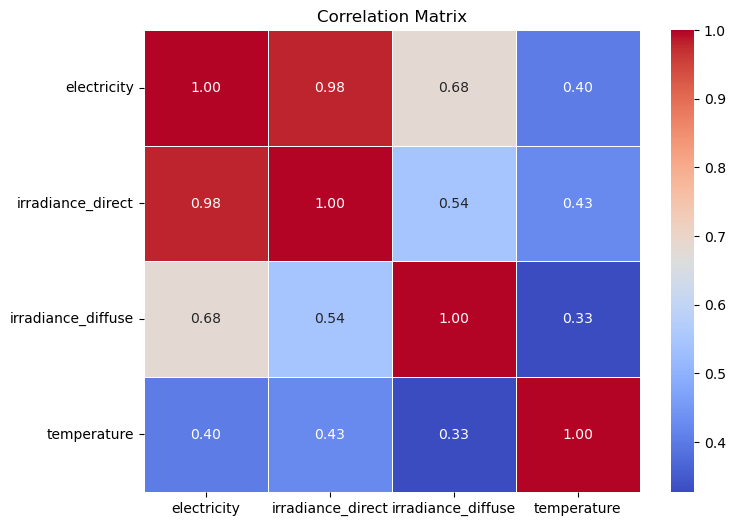

In [10]:
# Calculating the correlation matrix
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix")
plt.show()

In [11]:
# The following steps were taken because we encountered an error before setting the frequency.

# 1. Check for duplicates
print("Number of duplicates:", df.index.duplicated().sum())

# 3. Or just remove duplicates (if the data points are identical)
df = df[~df.index.duplicated(keep='first')]

# 4. Set the frequency (Resample to 60 minutes)
df = df.asfreq('60T')

# 5. Verification
print("Final frequency:", df.index.freq)

# Display rows that have at least one NaN value (introduced by asfreq)
rows_with_nan = df[df.isna().any(axis=1)]

print("Rows with NaN:")
print(rows_with_nan)

# Fill missing values: backward fill, then forward fill to handle remaining NaNs at the start.
df = df.fillna(method='bfill').fillna(method='ffill')

Number of duplicates: 1
Final frequency: <60 * Minutes>
Rows with NaN:
                     electricity  irradiance_direct  irradiance_diffuse  \
local_time                                                                
2019-03-22 00:30:00          NaN                NaN                 NaN   

                     temperature  
local_time                        
2019-03-22 00:30:00          NaN  


C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\529074595.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df.asfreq('60T')
C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\529074595.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


The result obtained from lag_at_max tells you the time delay (e.g., how many hours) with which solar radiation has the maximum impact on electricity generation. Physically, this value is expected to be close to zero, as solar power generation occurs almost instantaneously following light exposure.

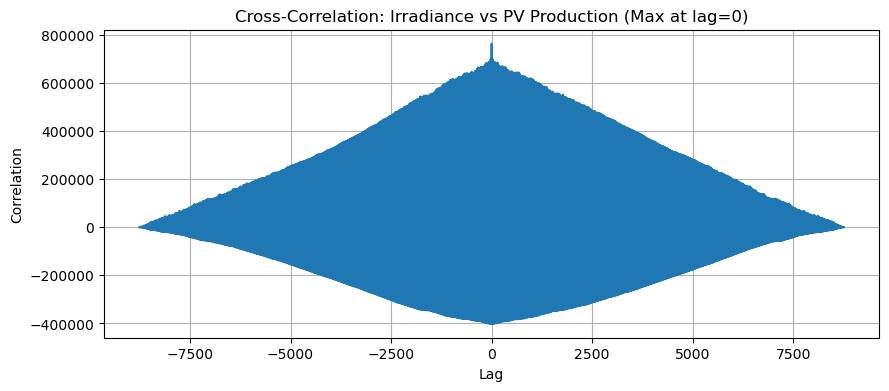

np.int64(0)

In [12]:
def plot_cross_correlation(x, y, labels=["X", "Y"]):
    corr = correlate(x - x.mean(), y - y.mean())
    lags = np.arange(-len(x) + 1, len(y))
    lag_at_max = lags[np.argmax(corr)]

    plt.figure(figsize=(10, 4))
    plt.plot(lags, corr)
    plt.title(f"Cross-Correlation: {labels[0]} vs {labels[1]} (Max at lag={lag_at_max})")
    plt.xlabel("Lag")
    plt.ylabel("Correlation")
    plt.grid(True)
    plt.show()

    return lag_at_max


plot_cross_correlation(df["irradiance_direct"], df["electricity"],
                       labels=["Irradiance", "PV Production"])

# **1. Statistical Features**

In [13]:
def extended_describe(df):
    desc = df.describe()
    desc.loc['skewness'] = df.skew()
    desc.loc['kurtosis'] = df.kurt()
    desc.loc['range'] = df.max() - df.min()
    return desc


extended_describe(df)

,electricity,irradiance_direct,irradiance_diffuse,temperature
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,210.687661,0.217537,0.049924,17.258159
std,278.712631,0.318594,0.065406,11.415465
min,0.000000,0.000000,0.000000,-3.282000
25%,0.000000,0.000000,0.000000,7.456750
50%,2.251500,0.000000,0.008000,16.512000
75%,448.966250,0.409250,0.090000,26.215250
max,889.482000,1.050000,0.393000,43.024000
skewness,0.898439,1.150617,1.644973,0.231786
kurtosis,-0.810950,-0.240465,3.427034,-1.003835


# **2.Time-Domain Features**

In [5]:


# Sort the DataFrame by 'local_time' in ascending order.
# Sorting ensures that time-series operations or sequential analysis are performed correctly.
# df = df.sort_values('local_time')

# Create a date column with only dates (no time)
df['date'] = df.index.date

# Extract the hour of the day from the 'local_time' column.
# The '.dt.hour' accessor returns the hour as an integer (0 to 23).
df['hour'] = df.index.hour
df['day'] = df.index.day


# Extract the day of the week from the 'local_time' column.
# The '.dt.dayofweek' accessor returns the day of the week as an integer (0 for Monday, 6 for Sunday).
df['dayofweek'] = df.index.dayofweek

# Extract the month from the 'local_time' column.
# The '.dt.month' accessor returns the month as an integer (1 for January, 12 for December).
df['month'] = df.index.month

# Create a binary feature 'is_daytime' indicating whether the hour falls within daytime (6 AM to 6 PM).
# '.between(6, 18)' checks if the 'hour' is within the inclusive range [6, 18].
# '.astype(int)' converts the boolean result (True/False) to an integer (1/0).
df['is_daytime'] = df['hour'].between(6, 18).astype(int)

# Create a 'week' column by extracting the ISO week number from the 'local_time' column.
# '.dt.isocalendar().week' returns the week number according to the ISO 8601 standard.
df['week'] = df.index.isocalendar().week

In [15]:
df.columns

Index(['electricity', 'irradiance_direct', 'irradiance_diffuse', 'temperature',
       'date', 'hour', 'day', 'dayofweek', 'month', 'is_daytime', 'week'],
      dtype='object')

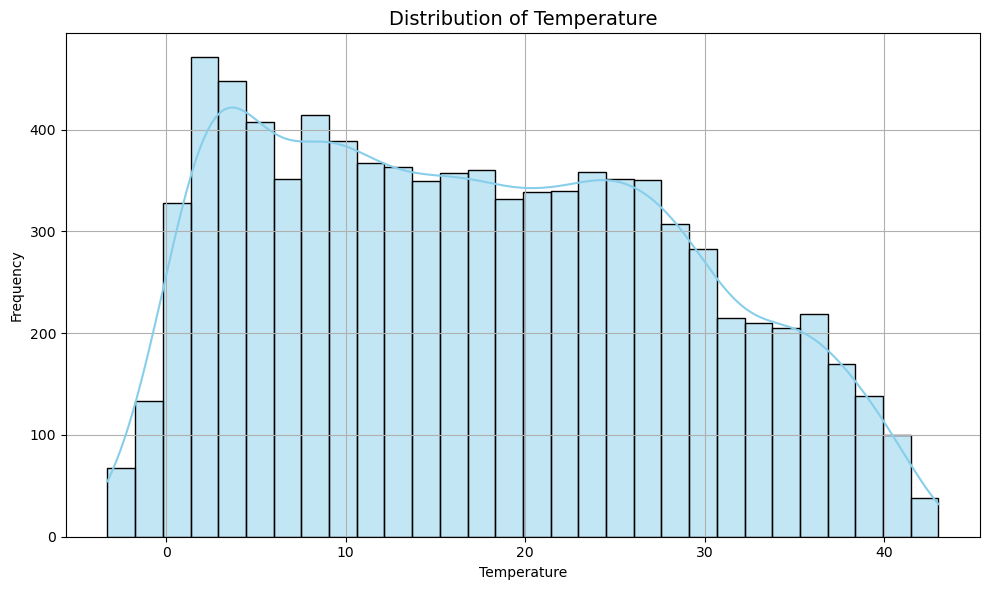

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['temperature'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Temperature', fontsize=14)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

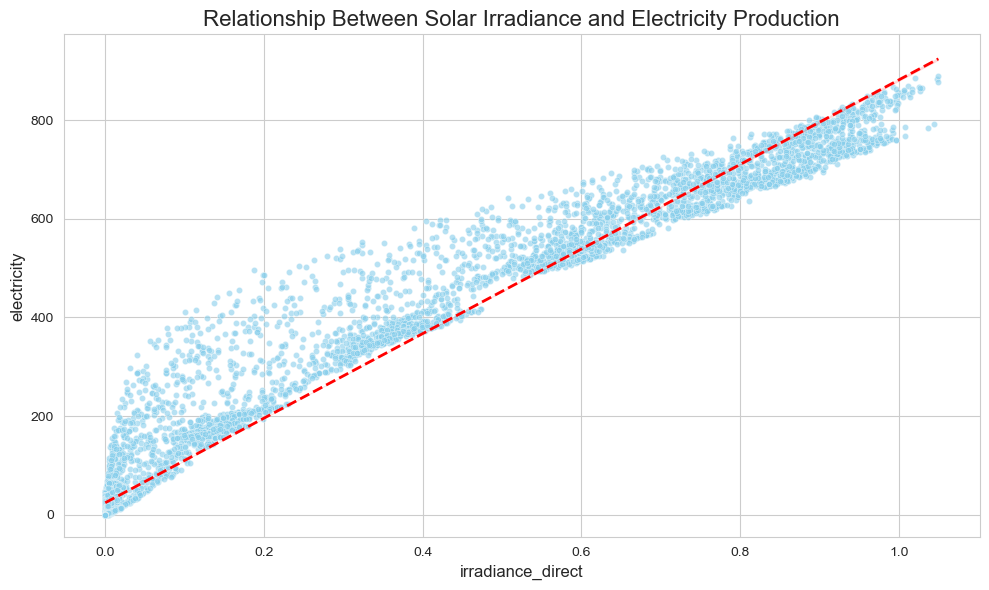

In [17]:
# Set a professional plot style
sns.set_style("whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6)) # Adjust figure size for better visibility
sns.scatterplot(
    data=df,
    x='irradiance_direct',
    y='electricity',
    alpha=0.6, # Make points slightly transparent to see density
    color='skyblue',
    s=20 # Adjust point size
)

# Add a title and labels
plt.title('Relationship Between Solar Irradiance and Electricity Production', fontsize=16)
plt.xlabel('Direct Solar Irradiance', fontsize=12)
plt.ylabel('Electricity Production', fontsize=12)

# Add a line of best fit to show the trend
sns.regplot(
    data=df,
    x='irradiance_direct',
    y='electricity',
    scatter=False, # Don't plot the scatter points again
    color='red',
    line_kws={'linestyle': '--', 'linewidth': 2}
)

# Show the plot
plt.tight_layout()
plt.show()

<Axes: xlabel='irradiance_direct', ylabel='irradiance_diffuse'>

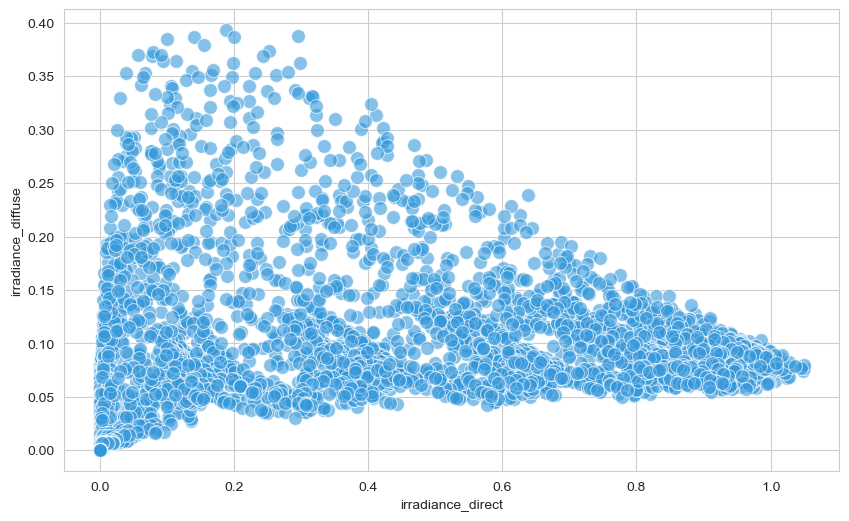

In [18]:
# Set a professional style for the plot
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8-deep')

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='irradiance_direct',
    y='irradiance_diffuse',
    data=df,
    s=100,  # Size of the points
    alpha=0.6,  # Transparency of the points
    color='#3498db'  # A nice blue color
)

# # Add title and labels with clear, professional fonts
# plt.title('Relationship Between Direct and Diffuse Irradiance', fontsize=16, pad=20)
# plt.xlabel('Direct Irradiance', fontsize=12)
# plt.ylabel('Diffuse Irradiance', fontsize=12)

# # Add a text annotation to explain the relationship
# plt.text(
#     x=400,
#     y=240,
#     s='Note: A slight negative correlation is expected.\nAs direct sunlight increases, diffuse radiation often decreases.',
#     fontsize=10,
#     ha='center',
#     bbox=dict(boxstyle="round,pad=0.5", fc='yellow', alpha=0.5)
# )

# plt.grid(True)
# plt.show()

# **Heatmap of Average Electricity Production by Hour and Day**

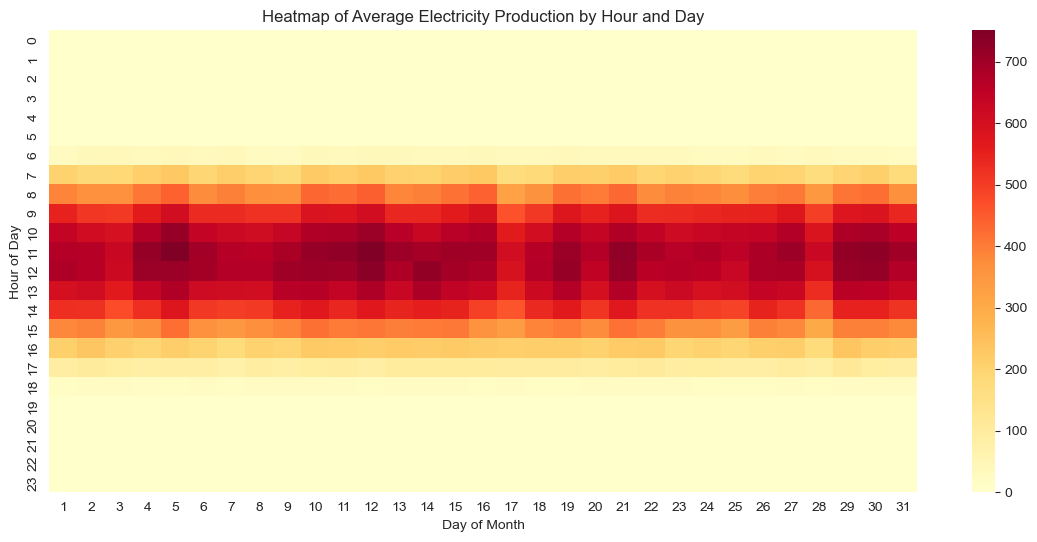

In [19]:
pivot_table = df.pivot_table(index='hour', columns='day', values='electricity', aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Heatmap of Average Electricity Production by Hour and Day')
plt.xlabel('Day of Month')
plt.ylabel('Hour of Day')
plt.show()

# **Hours Without Electricity Production and Average Daily Electricity Output**

This graph simultaneously displays the number of times electricity generation was zero during each hour of the day (shown by the red bars) and the average electricity generation for that same hour (shown by the blue line). This information helps to identify the hours where the probability of an outage or zero generation is high, as well as the overall electricity generation patterns throughout the day-night cycle.

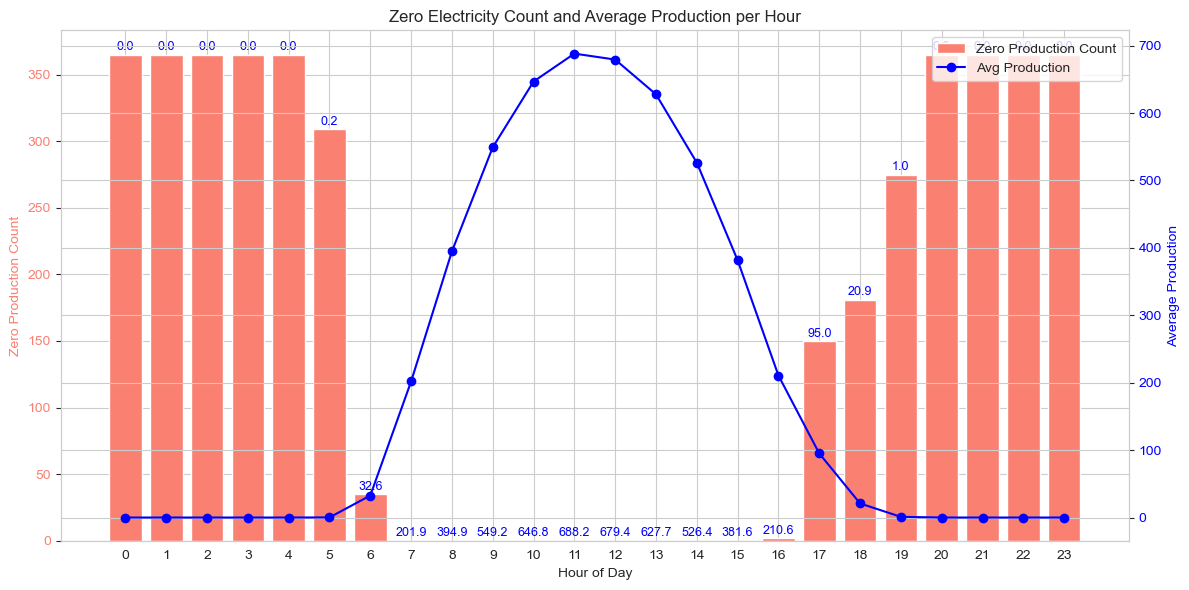

In [20]:
# Calculate the number of times electricity production was zero for each hour of the day.
# First, filter the DataFrame for rows where 'electricity' is 0.
# Then, count the occurrences of each 'hour' in this filtered subset.
zero_counts = df[df['electricity'] == 0]['hour'].value_counts()

# Create a complete Series for all 24 hours (0-23) initialized with zero counts.
# This ensures that even hours with no zero production events are included in the plot.
all_hours = pd.Series(0, index=range(24))

# Add the 'zero_counts' to 'all_hours'. If an hour is missing in 'zero_counts', it will default to 0.
zero_counts_full = all_hours.add(zero_counts, fill_value=0)

# Calculate the mean electricity production for each hour of the day.
mean_production = df.groupby('hour')['electricity'].mean()

# Create a figure and a set of subplots for a dual-axis chart.
# 'figsize' sets the size of the figure to 12 inches wide and 6 inches tall.
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the 'Zero Production Count' as a bar chart on the first y-axis (ax1).
bars = ax1.bar(zero_counts_full.index, zero_counts_full.values, color='salmon', label='Zero Production Count')
ax1.set_xlabel('Hour of Day') # Set the label for the x-axis.
ax1.set_ylabel('Zero Production Count', color='salmon') # Set the label for the left y-axis with a specific color.
ax1.tick_params(axis='y', labelcolor='salmon') # Set the tick label color for the left y-axis.
ax1.set_xticks(range(24)) # Ensure all 24 hours are displayed as x-ticks.
ax1.set_title("Zero Electricity Count and Average Production per Hour") # Set the title of the plot.

# Create a second y-axis that shares the same x-axis as ax1.
ax2 = ax1.twinx()

# Plot the 'Average Production' as a line chart on the second y-axis (ax2).
ax2.plot(mean_production.index, mean_production.values, color='blue', marker='o', label='Avg Production')
ax2.set_ylabel('Average Production', color='blue') # Set the label for the right y-axis with a specific color.
ax2.tick_params(axis='y', labelcolor='blue') # Set the tick label color for the right y-axis.

# Add the average production value as text above each bar.
# Loop through each hour from 0 to 23.
for i in range(24):
    # Get the average production value for the current hour; default to 0 if not present.
    avg_val = mean_production.get(i, 0)
    # Add text to ax1 at the top of each bar:
    # - 'i': x-coordinate (hour).
    # - 'zero_counts_full[i] + 1': y-coordinate (slightly above the bar).
    # - f'{avg_val:.1f}': Formatted average value with one decimal place.
    # - 'ha='center'': Horizontal alignment of the text.
    # - 'va='bottom'': Vertical alignment of the text.
    # - 'fontsize=9': Font size of the text.
    # - 'color='blue'': Color of the text.
    ax1.text(i, zero_counts_full[i] + 1, f'{avg_val:.1f}', ha='center', va='bottom', fontsize=9, color='blue')

# Add a legend to the figure.
# 'loc='upper right'': Places the legend in the upper right corner of the figure.
# 'bbox_to_anchor=(1, 1)': Positions the legend relative to the figure's top-right corner.
# 'bbox_transform=ax1.transAxes': Ensures the legend position is relative to ax1's axes coordinates.
fig.legend(loc='upper right', bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

# **Average Electricity Production by Day of Week**

This bar chart displays the average electricity production for each day of the week. By examining it, one can compare electricity consumption and production patterns between weekdays and weekends, identifying days with peak or low production.

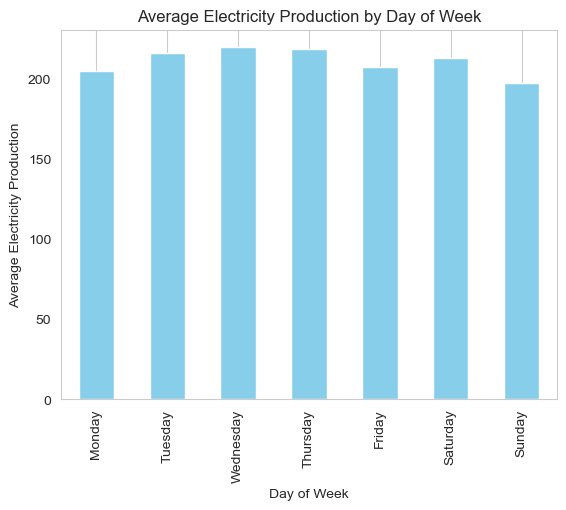

In [21]:
# Calculate the average electricity production for each day of the week.
# Group the DataFrame by 'dayofweek' and then compute the mean of 'electricity'.
avg_by_day = df.groupby('dayofweek')['electricity'].mean()

# Define a list of day names in order from Monday to Sunday.
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Map the numerical dayofweek index to the corresponding day names for better readability on the plot.
avg_by_day.index = day_names

# Create a bar plot using the calculated average electricity production per day.
# 'kind='bar'' specifies a bar chart.
# 'color='skyblue'' sets the color of the bars.
avg_by_day.plot(kind='bar', color='skyblue')

# Set the title of the plot.
plt.title('Average Electricity Production by Day of Week')

# Set the label for the x-axis.
plt.xlabel('Day of Week')

# Set the label for the y-axis.
plt.ylabel('Average Electricity Production')

# Add a horizontal grid to the plot for better readability.
plt.grid(axis='y')

# Display the plot.
plt.show()

<Axes: xlabel='is_daytime'>

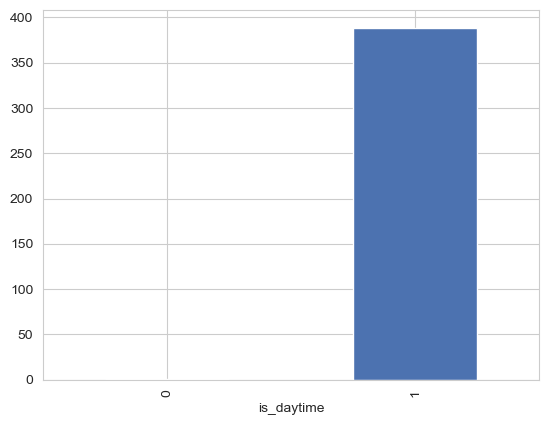

In [22]:
df.groupby('is_daytime')['electricity'].mean().plot(kind='bar')

# **Comparison of Monthly Average and Total Electricity Production**



These plots simultaneously display the daily average and total electricity production for each month of the year. The month with the highest average and the month with the highest total production are highlighted in orange, providing insight into seasonal electricity production patterns and overall system efficiency.

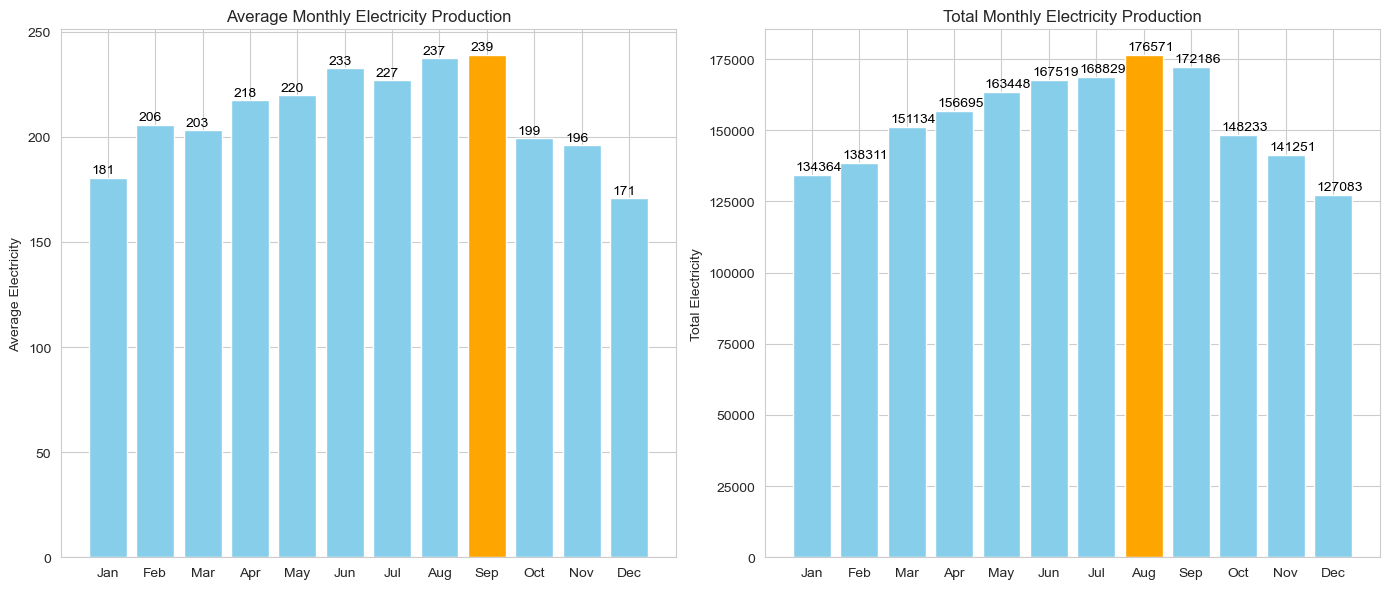

In [23]:
# List of month names for x-axis labels.
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate monthly average and total electricity production.
monthly_avg = df.groupby('month')['electricity'].mean()
monthly_sum = df.groupby('month')['electricity'].sum()

# Find the month with the highest average and highest total production.
max_avg_month = monthly_avg.idxmax()
max_sum_month = monthly_sum.idxmax()

# Define colors for the bars.
base_color = 'skyblue'
highlight_color = 'orange'

# Create color lists for average and total plots, highlighting the max month.
avg_colors = [highlight_color if m == max_avg_month else base_color for m in monthly_avg.index]
sum_colors = [highlight_color if m == max_sum_month else base_color for m in monthly_sum.index]

# Create a figure and a set of subplots (1 row, 2 columns).
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Monthly Average Electricity Production ---
axs[0].bar(monthly_avg.index, monthly_avg.values, color=avg_colors)
axs[0].set_xticks(range(1, 13)) # Set x-ticks for all 12 months.
axs[0].set_xticklabels(month_names) # Set month names as x-axis labels.
axs[0].set_title('Average Monthly Electricity Production')
axs[0].set_ylabel('Average Electricity')
axs[0].grid(True, axis='y') # Add horizontal grid lines.

# Display numeric values on top of each bar.
for i, v in enumerate(monthly_avg.values):
    # Position text slightly above the bar.
    axs[0].text(i + 1 - 0.35, v + 2, f'{v:.0f}', color='black')

# --- Plot 2: Total Monthly Electricity Production ---
axs[1].bar(monthly_sum.index, monthly_sum.values, color=sum_colors)
axs[1].set_xticks(range(1, 13)) # Set x-ticks for all 12 months.
axs[1].set_xticklabels(month_names) # Set month names as x-axis labels.
axs[1].set_title('Total Monthly Electricity Production')
axs[1].set_ylabel('Total Electricity')
axs[1].grid(True, axis='y') # Add horizontal grid lines.

# Display numeric values on top of each bar.
for i, v in enumerate(monthly_sum.values):
    # Position text slightly above the bar, scaled by a small percentage of max total production.
    axs[1].text(i + 1 - 0.35, v + max(monthly_sum.values)*0.01, f'{v:.0f}', color='black')

plt.tight_layout() # Adjust layout to prevent overlapping elements.
plt.show() # Display the plots.

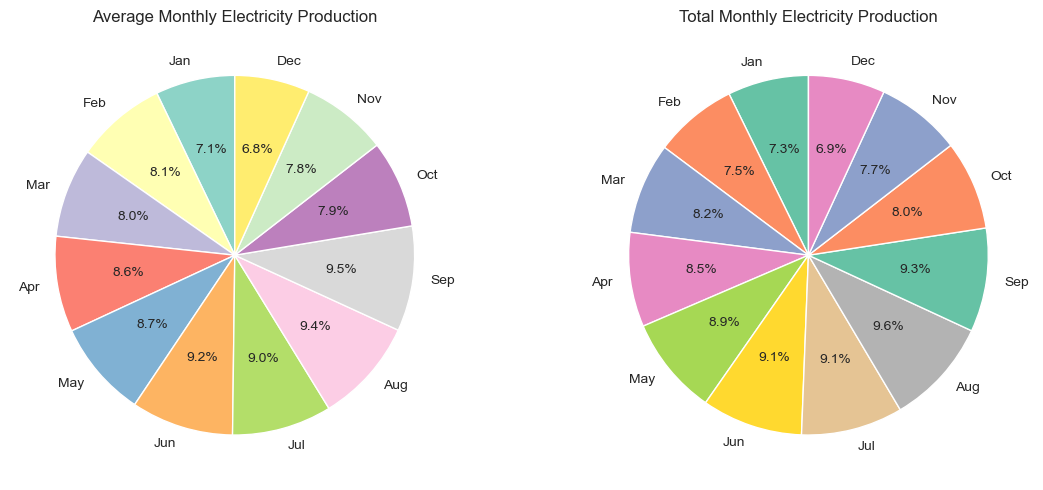

In [24]:
# List of month names for labels.
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Prepare values for plotting, ensuring all 12 months are represented even if data is missing.
avg_values = [monthly_avg.get(i+1, 0) for i in range(12)]
sum_values = [monthly_sum.get(i+1, 0) for i in range(12)]

# --- Plotting Average Pie Chart ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(avg_values, labels=month_names, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Average Monthly Electricity Production')

# --- Plotting Total Pie Chart ---
plt.subplot(1, 2, 2)
plt.pie(sum_values, labels=month_names, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Total Monthly Electricity Production')

plt.tight_layout()
plt.show()

# **Weekly Average Electricity Production Throughout the Year**

This plot displays the average electricity production on a weekly basis throughout a year. By examining this chart, one can observe seasonal patterns and variations in electricity production across different weeks of the year, identifying periods of peak or reduced output.

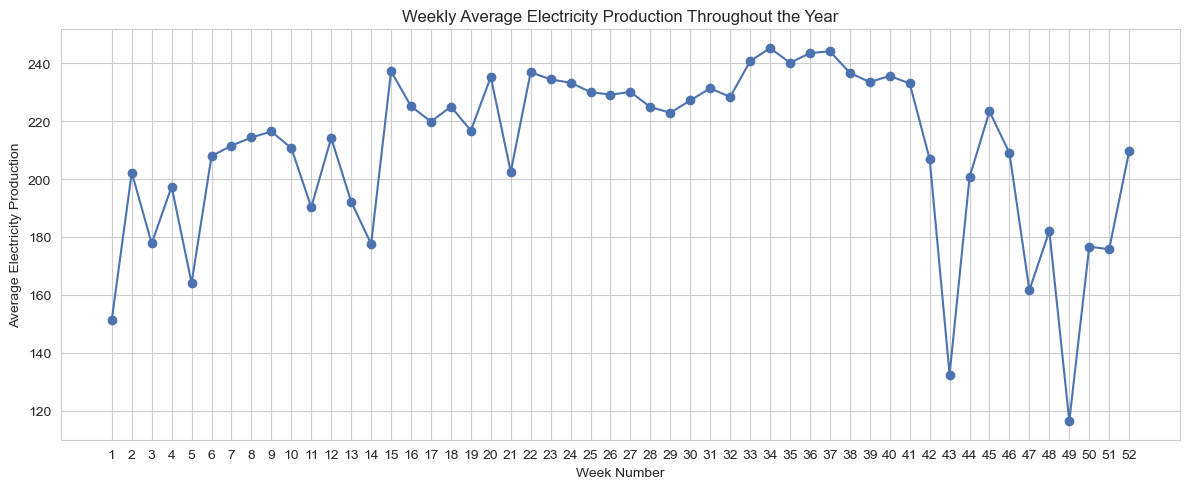

In [25]:
# Calculate the mean electricity production for each week.
# Group the DataFrame by the 'week' column and then compute the mean of the 'electricity' column for each group.
weekly_mean = df.groupby('week')['electricity'].mean()

# Create a new figure for the line plot with a specified size (12 inches wide, 5 inches tall).
plt.figure(figsize=(12, 5))

# Plot the 'Weekly Average Electricity Production' as a line chart.
# - 'weekly_mean.index': The week numbers for the x-axis.
# - 'weekly_mean.values': The average electricity production values for the y-axis.
# - 'marker='o'': Adds circular markers at each data point.
# - 'linestyle='-': Connects the data points with a solid line.
plt.plot(weekly_mean.index, weekly_mean.values, marker='o', linestyle='-')

# Set the title of the plot.
plt.title('Weekly Average Electricity Production Throughout the Year')

# Set the label for the x-axis.
plt.xlabel('Week Number')

# Set the label for the y-axis.
plt.ylabel('Average Electricity Production')

# Add a grid to the plot for better readability.
plt.grid(True)

# --- Modification to display all week numbers on the x-axis ---
# Determine the range of week numbers present in the data.
min_week = int(df['week'].min())
max_week = int(df['week'].max())
# Set the x-axis ticks to display every week number within the observed range.
plt.xticks(range(min_week, max_week + 1))


# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()

# Display the generated plot.
plt.show()

# **Daily Electricity Production Volatility per Month**


This box plot visualizes the volatility and spread of daily electricity production for each month. By examining this distribution (including median, quartiles, range, and outliers), one can clearly understand the extent and pattern of fluctuations in electricity generation across the days of each month, as well as compare these volatility patterns between different months.

C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\83984939.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='month', y='electricity', data=daily_avg, palette='Set2')


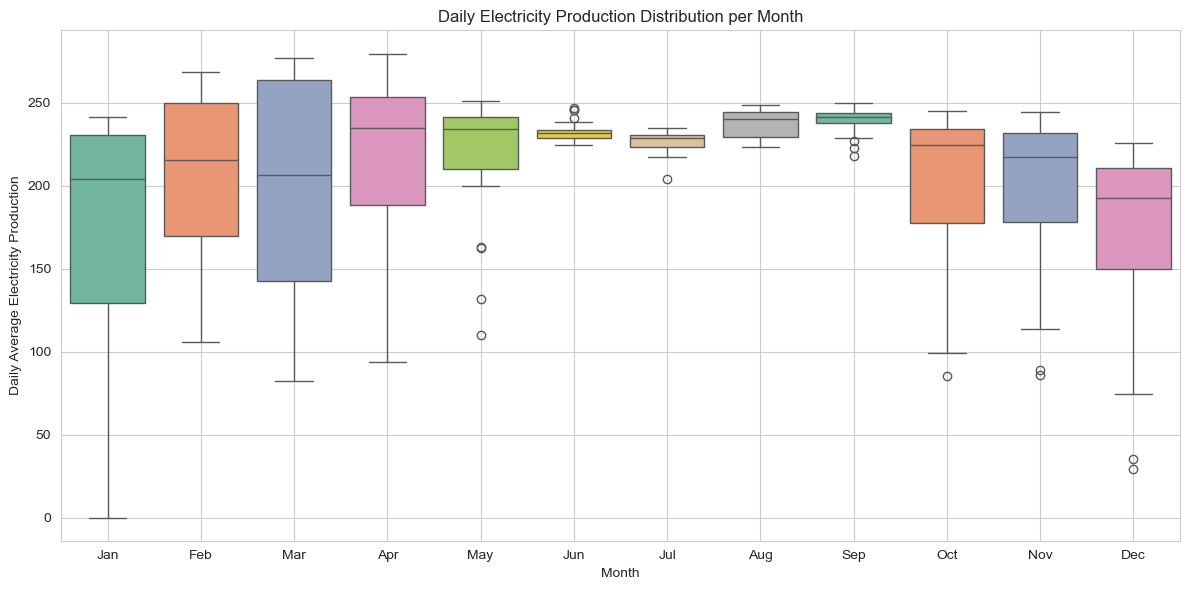

In [26]:
# Calculate the daily average electricity production.
# Group the DataFrame by 'date' and 'month', then compute the mean of 'electricity' for each group.
daily_avg = df.groupby(['date', 'month'])['electricity'].mean().reset_index()

# Create a new figure for the box plot with a specified size.
plt.figure(figsize=(12, 6))

# Generate a box plot:
# - 'x='month'': Sets the x-axis to represent months.
# - 'y='electricity'': Sets the y-axis to represent the daily average electricity production.
# - 'data=daily_avg': Specifies the DataFrame to use for plotting.
# - 'palette='Set2'': Sets the color palette for the boxes.
sns.boxplot(x='month', y='electricity', data=daily_avg, palette='Set2')

# Change numerical month labels to month names on the x-axis.
plt.xticks(ticks=range(12), labels=month_names)

# Set the title of the plot.
plt.title('Daily Electricity Production Distribution per Month')

# Set the label for the x-axis.
plt.xlabel('Month')

# Set the label for the y-axis.
plt.ylabel('Daily Average Electricity Production')

# Add a grid to the plot for better readability.
plt.grid(True)

# Adjust plot parameters for a tight layout, preventing labels from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

# **Monthly Relationship Between Electricity Production and Direct Solar Irradiance**

This dual-axis line plot simultaneously displays the monthly average electricity production and the monthly average direct solar irradiance. By observing this chart, one can identify the correlation between solar irradiance levels and electricity production throughout the different months of the year, expecting electricity production to increase with higher irradiance.

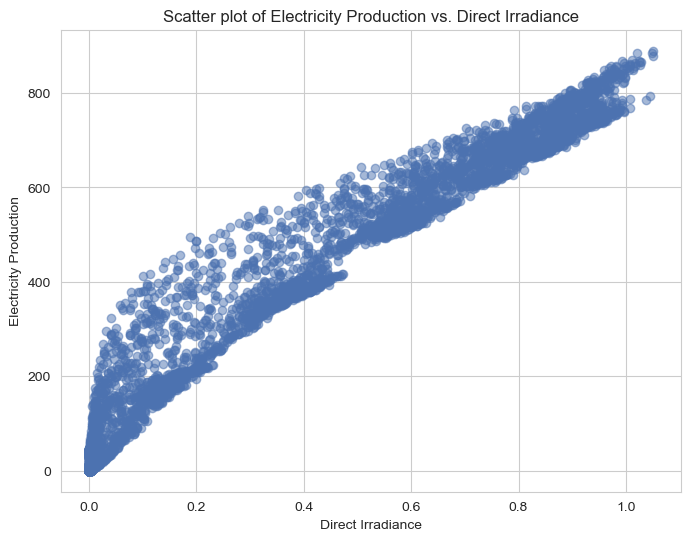

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(df['irradiance_direct'], df['electricity'], alpha=0.5)
plt.title('Scatter plot of Electricity Production vs. Direct Irradiance')
plt.xlabel('Direct Irradiance')
plt.ylabel('Electricity Production')
plt.grid(True)
plt.show()

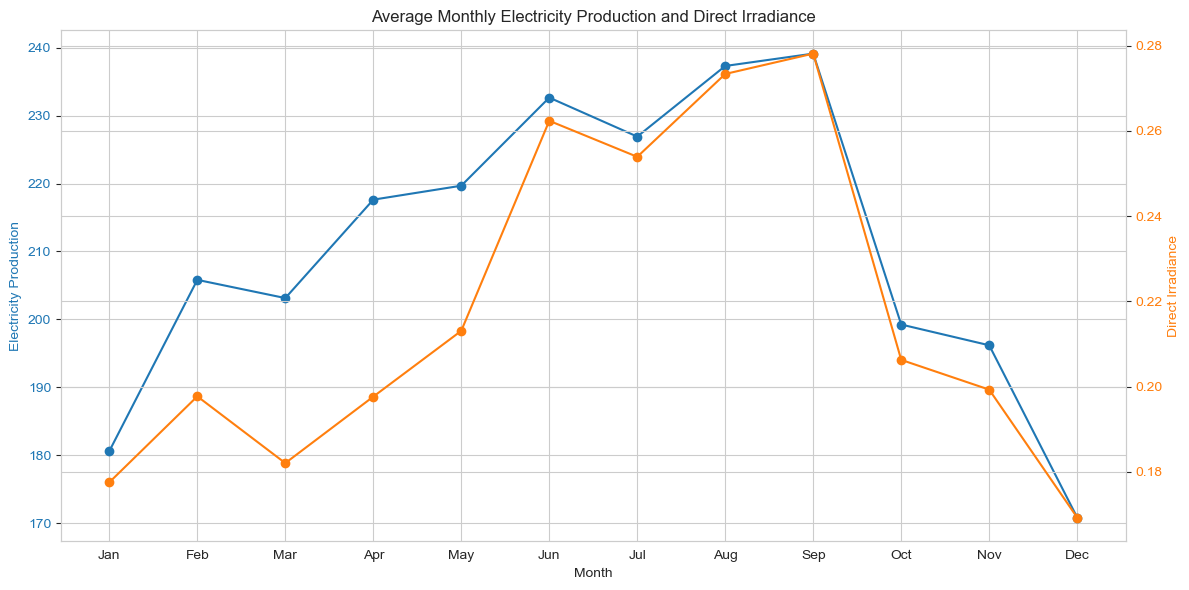

In [28]:
# Calculate the monthly average for both 'electricity' and 'irradiance_direct'.
monthly_avg = df.groupby('month')[['electricity', 'irradiance_direct']].mean().reset_index()

# List of month names for x-axis labels.
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create a figure and a primary axes object for a dual-axis plot.
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plotting Electricity Production on Primary Y-axis ---
color1 = 'tab:blue'
ax1.set_xlabel('Month') # Set x-axis label.
ax1.set_ylabel('Electricity Production', color=color1) # Set primary y-axis label and color.
ax1.plot(monthly_avg['month'], monthly_avg['electricity'], color=color1, marker='o', label='Electricity') # Plot electricity data.
ax1.tick_params(axis='y', labelcolor=color1) # Set tick label color for primary y-axis.
ax1.set_xticks(monthly_avg['month']) # Set x-ticks to correspond to months.
ax1.set_xticklabels(month_names) # Set month names as x-tick labels.

# --- Plotting Direct Irradiance on Secondary Y-axis ---
ax2 = ax1.twinx() # Create a second y-axis sharing the same x-axis.
color2 = 'tab:orange'
ax2.set_ylabel('Direct Irradiance', color=color2) # Set secondary y-axis label and color.
ax2.plot(monthly_avg['month'], monthly_avg['irradiance_direct'], color=color2, marker='o', label='Irradiance Direct') # Plot irradiance data.
ax2.tick_params(axis='y', labelcolor=color2) # Set tick label color for secondary y-axis.

plt.title('Average Monthly Electricity Production and Direct Irradiance') # Set the main title of the plot.
fig.tight_layout() # Adjust layout to prevent overlapping elements.
plt.show() # Display the plot.

# **Monthly Relationship Between Average Electricity Production and Temperature**

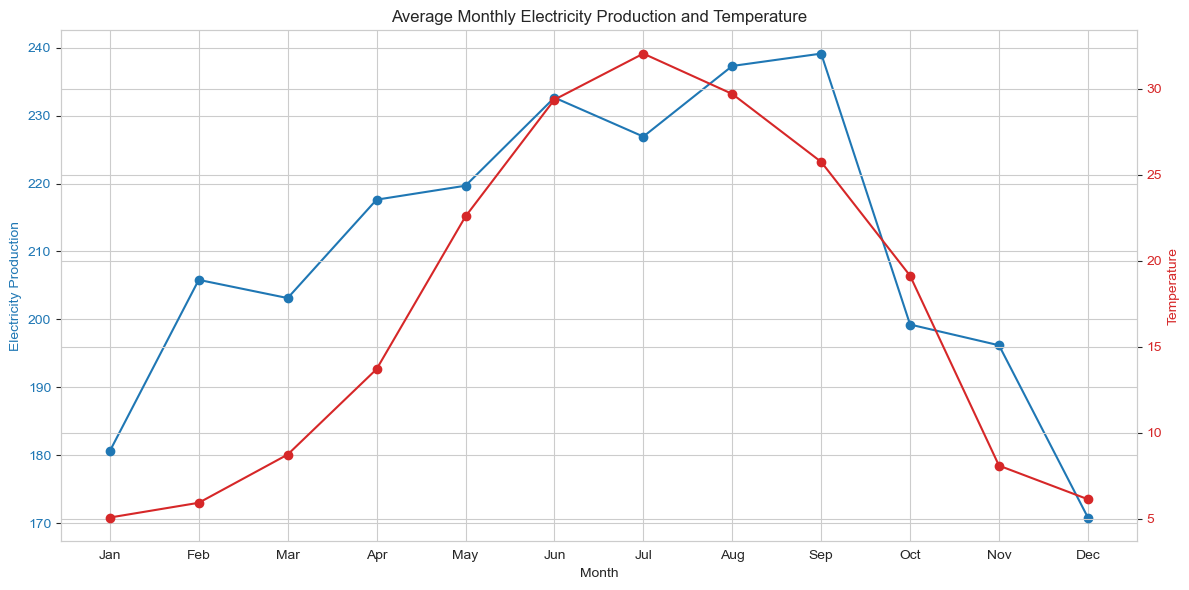

In [29]:
# Calculate the monthly average for both 'electricity' and 'temperature'.
monthly_avg = df.groupby('month')[['electricity', 'temperature']].mean().reset_index()

# List of month names for x-axis labels.
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Create a figure and a primary axes object for a dual-axis plot.
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plotting Electricity Production on Primary Y-axis ---
color1 = 'tab:blue'
ax1.set_xlabel('Month') # Set x-axis label.
ax1.set_ylabel('Electricity Production', color=color1) # Set primary y-axis label and color.
ax1.plot(monthly_avg['month'], monthly_avg['electricity'], color=color1, marker='o', label='Electricity') # Plot electricity data.
ax1.tick_params(axis='y', labelcolor=color1) # Set tick label color for primary y-axis.
ax1.set_xticks(monthly_avg['month']) # Set x-ticks to correspond to months.
ax1.set_xticklabels(month_names) # Set month names as x-tick labels.

# --- Plotting Temperature on Secondary Y-axis ---
ax2 = ax1.twinx() # Create a second y-axis sharing the same x-axis.
color2 = 'tab:red'
ax2.set_ylabel('Temperature', color=color2) # Set secondary y-axis label and color.
ax2.plot(monthly_avg['month'], monthly_avg['temperature'], color=color2, marker='o', label='Temperature') # Plot temperature data.
ax2.tick_params(axis='y', labelcolor=color2) # Set tick label color for secondary y-axis.

plt.title('Average Monthly Electricity Production and Temperature') # Set the main title of the plot.
fig.tight_layout() # Adjust layout to prevent overlapping elements.
plt.show() # Display the plot.

# **sktime**

In [30]:
# --- 1. Data Preparation ---
# Target variable (electricity generation)
y = df["electricity"].copy()
# Features: all numeric columns except the target
X = df.drop(columns=["electricity"]).select_dtypes(include=[np.number])

# Fill missing values in features (Backward Fill then Forward Fill)
X = X.fillna(method='bfill').fillna(method='ffill')
# Fill missing values in target (Backward Fill)
y = y.fillna(method='bfill')

# Split data into training and test sets (test size = 7 days * 24 hours)
y_train, y_test, X_train, X_test = temporal_train_test_split(y, X, test_size=24*7)

# --- 2. Models with window_length ---
# Using make_reduction with window_length, not WindowSummarizer transformer
forecasters = [
    # Random Forest with recursive strategy and 10 lags
    ("rf", make_reduction(RandomForestRegressor(n_estimators=100), strategy="recursive", window_length=10)),
    # Gradient Boosting Regressor with recursive strategy and 10 lags
    ("gbr", make_reduction(GradientBoostingRegressor(n_estimators=50), strategy="recursive", window_length=10)),
    # Ridge Regression with recursive strategy and 10 lags
    ("ridge", make_reduction(Ridge(), strategy="recursive", window_length=10)),
]

# Combine models into a multiplex forecaster for selection
forecaster = MultiplexForecaster(forecasters=forecasters)

# --- 3. No WindowSummarizer in the Pipeline ---
# Only MultiplexForecaster — no extra transformation needed
# (since make_reduction handles lag creation internally)

# --- 4. Cross-Validation Setup ---
# Use Expanding Window Splitter for time series cross-validation
cv = ExpandingWindowSplitter(
    # Set initial window size (e.g., total train length minus 3 days)
    initial_window=len(y_train) - 24*3,
    step_length=12,
    # Forecast horizon for 1, 2, and 3 steps ahead
    fh=ForecastingHorizon([1, 2, 3], is_relative=True)
)

# --- 5. GridSearch with Error Display ---
# Set up Grid Search for hyperparameter tuning (selecting the best forecaster)
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    cv=cv,
    # Parameter grid to select one of the defined forecasters
    param_grid={"selected_forecaster": ["rf", "gbr", "ridge"]},
    scoring=mean_absolute_error,
    error_score='raise',  # ✅ Now the specific error will be displayed if fitting fails
    verbose=2
)

# --- 6. Fit the Model ---
try:
    gscv.fit(y_train, X=X_train)
except Exception as e:
    # Print the specific error for debugging
    print("❌ Detailed Error:", e)
    raise # Re-raise the exception to stop execution

C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\1333839291.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill').fillna(method='ffill')
C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\1333839291.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = y.fillna(method='bfill')


Fitting 6 folds for each of 3 candidates, totalling 18 fits


In [32]:
# Extract the name of the best forecaster selected by Grid Search
best_model = gscv.best_params_["selected_forecaster"]
print(f"✅ Best selected model: {best_model}")

# Define the forecasting horizon: predict for the next 24 steps (hours)
fh = ForecastingHorizon(np.arange(1, 25), is_relative=True)

# Generate predictions using the best model from the Grid Search
# We use the first 24 rows of the test features (X_test) as exogenous data for the prediction
y_pred = gscv.predict(fh, X=X_test.iloc[:24])

✅ Best selected model: rf


MAE: 6.14


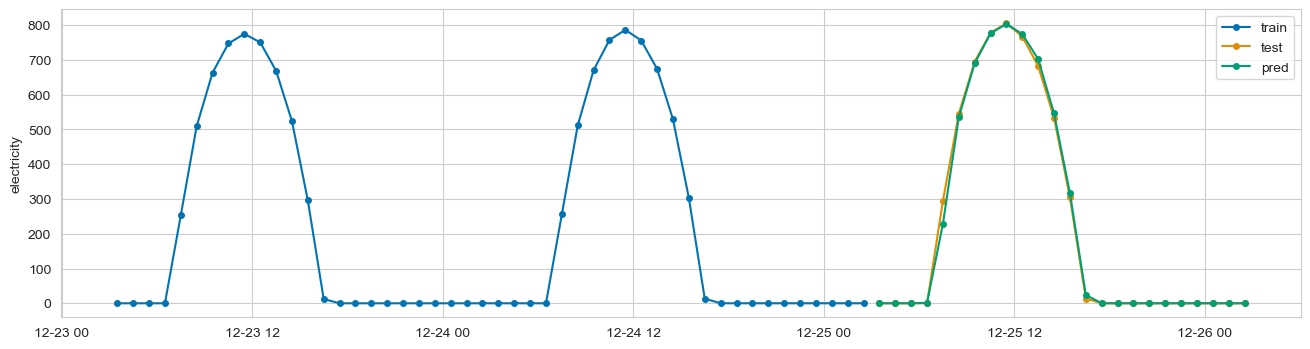

In [34]:
from sktime.utils.plotting import plot_series
# 12. Plotting the Results 
plot_series(
    y_train[-48:],  # Last 48 hours of training data
    y_test[:24],    # First 24 hours of actual test data
    y_pred,         # The 24-hour forecast (prediction)
    labels=["train", "test", "pred"]
)

# 13. Calculating the MAE Error
mae = mean_absolute_error(y_test[:24], y_pred)
print(f"MAE: {mae:.2f}")

# **LSTM Autoencoder for Anomaly Detection in Electricity Consumption:**


This code provides a complete Anomaly Detection system for electricity consumption time series data, utilizing the powerful combination of LSTM (Long Short-Term Memory) and an Autoencoder.

**Key Features:**

* Processing of time series data with consideration for the time index.

* Automatic creation of sequences for modeling temporal dependencies.

* Training exclusively on normal data to learn natural patterns.

* Calculation of the reconstruction error and determination of the optimal threshold.

* Comprehensive evaluation of model performance using various metrics.

* Ability to save and reuse the trained model.

**Main Application:**

Detecting anomalous patterns in electricity consumption, predicting equipment failure, and monitoring energy systems.

In [35]:
# 1. Daily Cycle: 'hour' feature
# Full cycle: 24 hours
hours_in_day = 24
df['sin_hour'] = np.sin(2 * math.pi * df['hour'] / hours_in_day)
df['cos_hour'] = np.cos(2 * math.pi * df['hour'] / hours_in_day)


# 2. Monthly Cycle: 'day' feature (day of the month)
# Full cycle: 31 days (to cover all months)
days_in_month_max = 31
df['sin_day_month'] = np.sin(2 * math.pi * df['day'] / days_in_month_max)
df['cos_day_month'] = np.cos(2 * math.pi * df['day'] / days_in_month_max)

# 3. Weekly Cycle: 'dayofweek' feature (day of the week, Monday=0, Sunday=6)
# Full cycle: 7 days
days_in_week = 7
df['sin_dayofweek'] = np.sin(2 * math.pi * df['dayofweek'] / days_in_week)
df['cos_dayofweek'] = np.cos(2 * math.pi * df['dayofweek'] / days_in_week)

print("Cyclic features (Sin/Cos) for hour, day of month, and day of week added.")
print(df[['hour', 'sin_hour', 'cos_hour', 'day', 'sin_day_month', 'cos_day_month']].head())

Cyclic features (Sin/Cos) for hour, day of month, and day of week added.
                     hour  sin_hour      cos_hour  day  sin_day_month  \
local_time                                                              
2019-01-01 03:30:00     3  0.707107  7.071068e-01    1       0.201299   
2019-01-01 04:30:00     4  0.866025  5.000000e-01    1       0.201299   
2019-01-01 05:30:00     5  0.965926  2.588190e-01    1       0.201299   
2019-01-01 06:30:00     6  1.000000  6.123234e-17    1       0.201299   
2019-01-01 07:30:00     7  0.965926 -2.588190e-01    1       0.201299   

                     cos_day_month  
local_time                          
2019-01-01 03:30:00        0.97953  
2019-01-01 04:30:00        0.97953  
2019-01-01 05:30:00        0.97953  
2019-01-01 06:30:00        0.97953  
2019-01-01 07:30:00        0.97953  


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2019-01-01 03:30:00 to 2020-01-01 02:30:00
Freq: 60min
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   electricity         8760 non-null   float64
 1   irradiance_direct   8760 non-null   float64
 2   irradiance_diffuse  8760 non-null   float64
 3   temperature         8760 non-null   float64
 4   date                8760 non-null   object 
 5   hour                8760 non-null   int32  
 6   day                 8760 non-null   int32  
 7   dayofweek           8760 non-null   int32  
 8   month               8760 non-null   int32  
 9   is_daytime          8760 non-null   int64  
 10  week                8760 non-null   UInt32 
 11  sin_hour            8760 non-null   float64
 12  cos_hour            8760 non-null   float64
 13  sin_day_month       8760 non-null   float64
 14  cos_day_month       8760 non-null   floa

C:\Users\Asus\AppData\Local\Temp\ipykernel_9352\3002230582.py:52: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill').fillna(method='ffill')


X_multi shape: (8736, 24, 11)
Number of features used: 11

Train shape: (5825, 24, 11)
Test shape: (1747, 24, 11)
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 1.2948 - mae: 0.8690 - val_loss: 1.1722 - val_mae: 0.8889
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.0610 - mae: 0.8363 - val_loss: 0.9980 - val_mae: 0.8405
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.9491 - mae: 0.7966 - val_loss: 0.8883 - val_mae: 0.7903
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.8927 - mae: 0.7664 - val_loss: 0.8247 - val_mae: 0.7438
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.8841 - mae: 0.7716 - val_loss: 0.8370 - val_mae: 0.7619
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.7910 - mae: 0.7033 - val_loss: 0.7644 - val_mae: 0.6955
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.7822 - mae: 0.6966 - val_loss: 0.7408 - val_mae: 0.6843
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss:

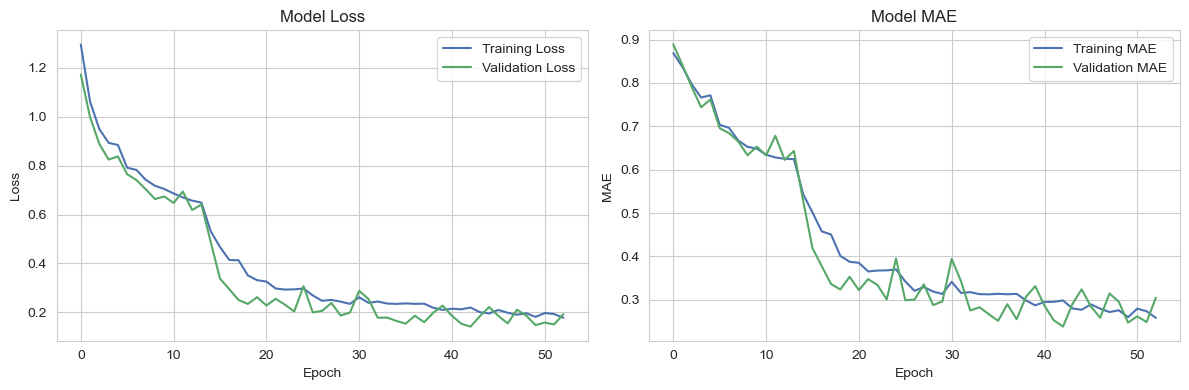


Anomaly threshold: 0.4726

Model Performance:
Accuracy: 0.9381797366914711

Confusion Matrix:
[[1639  108]
 [   0    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1747
           1       0.00      0.00      0.00         0

    accuracy                           0.94      1747
   macro avg       0.50      0.47      0.48      1747
weighted avg       1.00      0.94      0.97      1747



C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


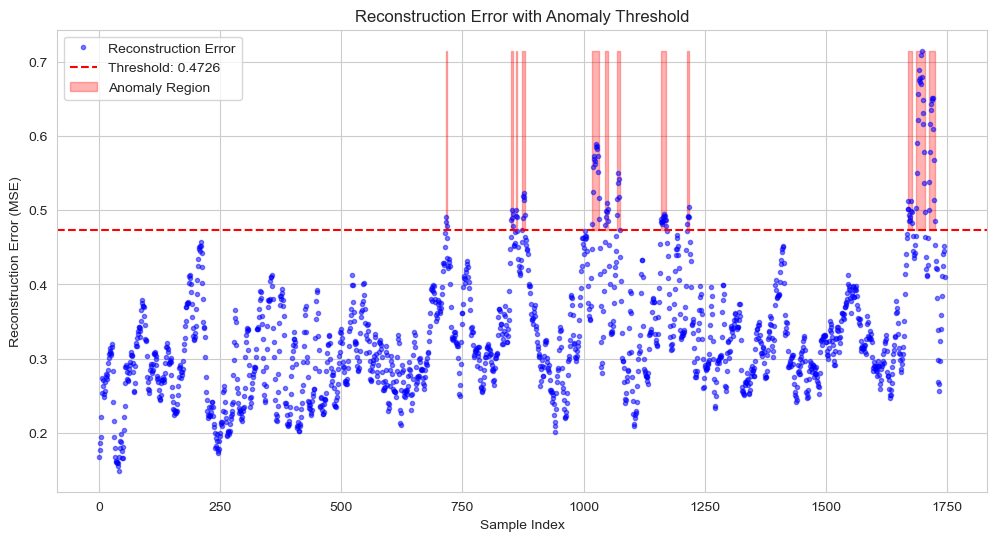


ANALYSIS RESULTS
Total sequences: 8736
Anomaly detection threshold: 0.4726
Test accuracy: 0.938

Detected 108 anomalies in test set
Sample anomaly indices: [715 716 717 851 852 853 854 855 860 861]


In [36]:
# 1. setup
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create a dummy 'label' column if it doesn't exist, assuming all are normal initially
if 'label' not in df.columns:
    df['label'] = 0

VALUE_COL = 'electricity'
LABEL_COL = 'label'

# Display DataFrame info and initial setup
print("DataFrame Info:")
print(df.info())
# ... (rest of print statements) ...

# Ensure index is datetime and sorted for time-series processing
if not isinstance(df.index, pd.DatetimeIndex):
    try:
        df.index = pd.to_datetime(df.index)
        print("Converted index to datetime")
    except:
        print("Could not convert index to datetime")

df = df.sort_index()
print("Data sorted by time index")

#2.Sequence Creation

# Function to create sequences (windows) from time-series data
def create_sequences(data, value_col, label_col, sequence_length=24):
    """
    Creates sequences from time series data for the Autoencoder.
    """
    sequences = [] # For the main value (electricity)
    labels = []
    final_feature_cols = [
    'electricity',
    'irradiance_direct',
    'irradiance_diffuse',
    'temperature',
    'is_daytime',

    'sin_hour', 'cos_hour',
    'sin_day_month', 'cos_day_month',
    'sin_dayofweek', 'cos_dayofweek',

]


    data = data.fillna(method='bfill').fillna(method='ffill')

    for i in range(len(data) - sequence_length):
        # Main value sequence (e.g., electricity)
        seq_combined = data[final_feature_cols].iloc[i:i+sequence_length].values

        label = data[label_col].iloc[i+sequence_length-1]

        sequences.append(seq_combined)
        labels.append(label)


    return np.array(sequences), np.array(labels), len(final_feature_cols)

# Parameters
SEQUENCE_LENGTH = 24 # Sequence length (e.g., a full day of hourly data)
NUM_FEATURES = 0

# ایجاد sequences
print("\nCreating multivariate sequences...")

X_multi, y, NUM_FEATURES = create_sequences(df, VALUE_COL, LABEL_COL, SEQUENCE_LENGTH)

print(f"X_multi shape: {X_multi.shape}")
print(f"Number of features used: {NUM_FEATURES}")

# .3.Data Splitting and Reshaping

# 1) Split data into Train/Validation/Test maintaining chronological order
test_size = int(len(X_multi) * 0.2)
X_trainval, X_test = X_multi[:-test_size], X_multi[-test_size:]
y_trainval, y_test = y[:-test_size], y[-test_size:]

# Use TimeSeriesSplit to create a chronological validation set
tscv = TimeSeriesSplit(n_splits=5)
train_idx, val_idx = list(tscv.split(X_trainval))[-1]
X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
y_train, y_val = y_trainval[train_idx], y_trainval[val_idx]

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")



X_train_normal = X_train[y_train == 0]
X_train_anomalous = X_train[y_train == 1]

# 4. Scaling and Autoencoder Model
# 4) Data Normalization
scaler = StandardScaler()

# Fit the scaler ONLY on the normal training data (critical for anomaly detection)
X_train_normal_flat = X_train_normal.reshape(-1, NUM_FEATURES)
scaler.fit(X_train_normal_flat)

# Transform all datasets
X_train_normal_scaled = scaler.transform(X_train_normal_flat).reshape(X_train_normal.shape)
X_train_scaled = scaler.transform(X_train.reshape(-1, NUM_FEATURES)).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val.reshape(-1, NUM_FEATURES)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, NUM_FEATURES)).reshape(X_test.shape)

# 5) Build the LSTM Autoencoder Model
def build_lstm_autoencoder_multi(input_shape, encoding_dim=32):
    #(SEQUENCE_LENGTH, NUM_FEATURES)
    input_layer = Input(shape=input_shape)

    # Encoder
    encoder = LSTM(encoding_dim, activation='relu', return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.01))(input_layer)
    encoder = Dense(encoding_dim // 2, activation='relu')(encoder)

    # Decoder
    repeat_vector = RepeatVector(input_shape[0])(encoder)
    decoder = LSTM(encoding_dim, activation='relu', return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.01))(repeat_vector)

    decoder = TimeDistributed(Dense(input_shape[1]))(decoder)

    autoencoder = Model(inputs=input_layer, outputs=decoder)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return autoencoder


autoencoder = build_lstm_autoencoder_multi(input_shape=(SEQUENCE_LENGTH, NUM_FEATURES))

# EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model ONLY with normal sequences
history = autoencoder.fit(
    X_train_normal_scaled, X_train_normal_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    shuffle=False
)
# ... (plot training history) ...
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Anomaly Detection and Evaluation
# Function to calculate reconstruction error (Mean Squared Error)
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data, verbose=0)
    mse = np.mean(np.square(data - reconstructions), axis=(1, 2))
    return mse

# Calculate error on normal training data and test data
train_error = calculate_reconstruction_error(autoencoder, X_train_normal_scaled)
test_error = calculate_reconstruction_error(autoencoder, X_test_scaled)

# Determine the threshold (95th percentile of the training error is a common choice)
threshold = np.percentile(train_error, 95)
print(f"\nAnomaly threshold: {threshold:.4f}")

# Predict anomalies on the test set
y_pred = (test_error > threshold).astype(int)

# Evaluation
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot reconstruction error with threshold
plt.figure(figsize=(12, 6))
plt.plot(test_error, 'b.', alpha=0.5, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
# Highlight the anomaly region (errors above the threshold)
plt.fill_between(range(len(test_error)), threshold, test_error.max(),
                 where=(test_error > threshold), color='red', alpha=0.3, label='Anomaly Region')
plt.title('Reconstruction Error with Anomaly Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Save the trained model and scaler
autoencoder.save('electricity_anomaly_detector.h5')
joblib.dump(scaler, 'electricity_scaler.pkl')
# ... (final analysis print statements) ...

print("\n" + "="*50)
print("ANALYSIS RESULTS")
print("="*50)
print(f"Total sequences: {len(X_multi)}")
print(f"Anomaly detection threshold: {threshold:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

anomaly_indices = np.where(y_pred == 1)[0]
if len(anomaly_indices) > 0:
    print(f"\nDetected {len(anomaly_indices)} anomalies in test set")
    print("Sample anomaly indices:", anomaly_indices[:10])




**1. Setup and Initial Data Prep**

In [6]:
# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create a dummy 'label' column if it doesn't exist, assuming all are normal initially
if 'label' not in df.columns:
    df['label'] = 0

# Define column names
VALUE_COL = 'electricity'
LABEL_COL = 'label'

# Display DataFrame info and initial setup
print("DataFrame Info:")
# Be careful: running df.info() in a notebook cell will output the info.
# print(df.info()) 
print(f"Total rows: {len(df)}")
print(f"Target column: {VALUE_COL}")

# Ensure index is datetime and sorted for time-series processing
if not isinstance(df.index, pd.DatetimeIndex):
    try:
        df.index = pd.to_datetime(df.index)
        print("Converted index to datetime")
    except:
        print("Could not convert index to datetime")

df = df.sort_index()
print("Data sorted by time index")

# Feature Engineering (as defined in your previous step for hour normalization)
# Note: Since the provided function only uses 'hour_norm', you should define it here.
hours_in_day = 24
df['hour_norm'] = df['hour'] / hours_in_day

DataFrame Info:
Total rows: 8760
Target column: electricity
Data sorted by time index


**2.Sequence Creation**

In [7]:
# Function to create sequences (windows) from time-series data
def create_sequences(data, value_col, label_col, sequence_length=24):
    """
    Creates sequences from time series data for the Autoencoder.
    """
    sequences = [] # For the main value (electricity)
    labels = []
    feature_cols = [value_col, 'temperature', 'irradiance_direct', 'hour']

    data['hour_norm'] = data['hour'] / 24.0
    final_feature_cols = [value_col, 'temperature', 'irradiance_direct', 'hour_norm']
    data = data.fillna(method='bfill').fillna(method='ffill')

    for i in range(len(data) - sequence_length):
        # Main value sequence (e.g., electricity)
        seq_combined = data[final_feature_cols].iloc[i:i+sequence_length].values

        label = data[label_col].iloc[i+sequence_length-1]

        sequences.append(seq_combined)
        labels.append(label)


    return np.array(sequences), np.array(labels), len(final_feature_cols)

# Parameters
SEQUENCE_LENGTH = 24 # Sequence length (e.g., a full day of hourly data)
NUM_FEATURES = 0

# creat sequences
print("\nCreating multivariate sequences...")

X_multi, y, NUM_FEATURES = create_sequences(df, VALUE_COL, LABEL_COL, SEQUENCE_LENGTH)

print(f"X_multi shape: {X_multi.shape}")
print(f"Number of features used: {NUM_FEATURES}")


Creating multivariate sequences...


C:\Users\Asus\AppData\Local\Temp\ipykernel_18164\4087919260.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill').fillna(method='ffill')


X_multi shape: (8736, 24, 4)
Number of features used: 4


**3.Data Splitting and Reshaping**

In [8]:
# 1) Split data into Train/Validation/Test maintaining chronological order
test_size = int(len(X_multi) * 0.2)
X_trainval, X_test = X_multi[:-test_size], X_multi[-test_size:]
y_trainval, y_test = y[:-test_size], y[-test_size:]

# Use TimeSeriesSplit to create a chronological validation set
tscv = TimeSeriesSplit(n_splits=5)
train_idx, val_idx = list(tscv.split(X_trainval))[-1]
X_train, X_val = X_trainval[train_idx], X_trainval[val_idx]
y_train, y_val = y_trainval[train_idx], y_trainval[val_idx]

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")



X_train_normal = X_train[y_train == 0]
X_train_anomalous = X_train[y_train == 1]




Train shape: (5825, 24, 4)
Test shape: (1747, 24, 4)


**4. Scaling and Autoencoder Model**

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 1.1765 - mae: 0.8195 - val_loss: 1.2534 - val_mae: 0.9201
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.9675 - mae: 0.7840 - val_loss: 1.0260 - val_mae: 0.8365
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.8269 - mae: 0.7177 - val_loss: 0.8584 - val_mae: 0.7424
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.7592 - mae: 0.6774 - val_loss: 0.8211 - val_mae: 0.7326
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.7403 - mae: 0.6768 - val_loss: 0.5730 - val_mae: 0.5548
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.5050 - mae: 0.5027 - val_loss: 0.3819 - val_mae: 0.4153
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.4291 - mae: 0.4486 - val_loss: 0.3098 - val_mae: 0.3558
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.3623 - mae: 0.3965 - val_loss: 0.2534 - val_mae: 0.3145
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - lo

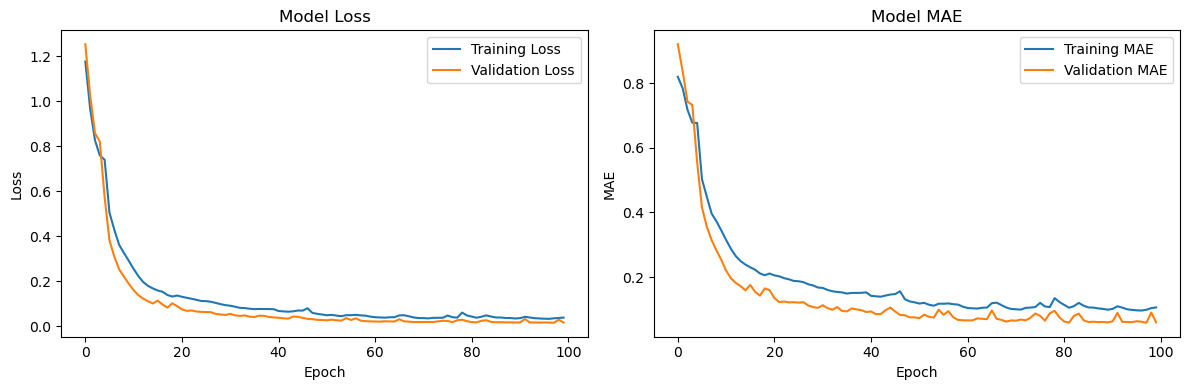

In [9]:
# 4) Data Normalization
scaler = StandardScaler()

# Fit the scaler ONLY on the normal training data (critical for anomaly detection)
X_train_normal_flat = X_train_normal.reshape(-1, NUM_FEATURES)
scaler.fit(X_train_normal_flat)

# Transform all datasets
X_train_normal_scaled = scaler.transform(X_train_normal_flat).reshape(X_train_normal.shape)
X_train_scaled = scaler.transform(X_train.reshape(-1, NUM_FEATURES)).reshape(X_train.shape)
X_val_scaled   = scaler.transform(X_val.reshape(-1, NUM_FEATURES)).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, NUM_FEATURES)).reshape(X_test.shape)

# 5) Build the LSTM Autoencoder Model
def build_lstm_autoencoder_multi(input_shape, encoding_dim=32):
    #(SEQUENCE_LENGTH, NUM_FEATURES)
    input_layer = Input(shape=input_shape)

    # Encoder
    encoder = LSTM(encoding_dim, activation='relu', return_sequences=False, kernel_regularizer=tf.keras.regularizers.l2(0.01))(input_layer)
    encoder = Dense(encoding_dim // 2, activation='relu')(encoder)

    # Decoder
    repeat_vector = RepeatVector(input_shape[0])(encoder)
    decoder = LSTM(encoding_dim, activation='relu', return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(0.01))(repeat_vector)

    decoder = TimeDistributed(Dense(input_shape[1]))(decoder)

    autoencoder = Model(inputs=input_layer, outputs=decoder)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return autoencoder


autoencoder = build_lstm_autoencoder_multi(input_shape=(SEQUENCE_LENGTH, NUM_FEATURES))

# EarlyStopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model ONLY with normal sequences
history = autoencoder.fit(
    X_train_normal_scaled, X_train_normal_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    shuffle=False
)
# ... (plot training history) ...
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()


**5. Anomaly Detection and Evaluation**


Anomaly threshold: 0.1151

Model Performance:
Accuracy: 0.9450486548368632

Confusion Matrix:
[[1651   96]
 [   0    0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1747
           1       0.00      0.00      0.00         0

    accuracy                           0.95      1747
   macro avg       0.50      0.47      0.49      1747
weighted avg       1.00      0.95      0.97      1747



C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Asus\.conda\envs\ds_base_env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


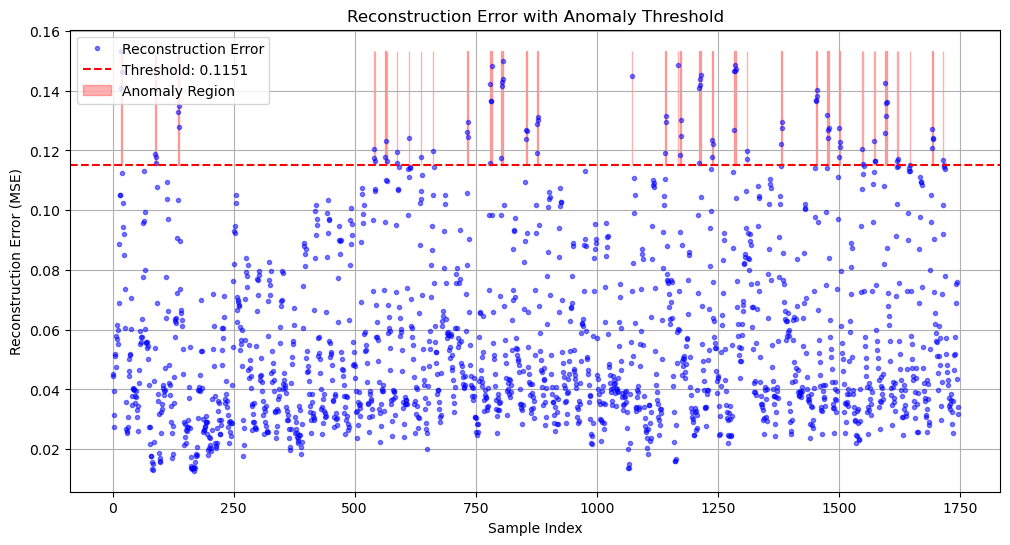


ANALYSIS RESULTS
Total sequences: 8736
Anomaly detection threshold: 0.1151
Test accuracy: 0.945

Detected 96 anomalies in test set
Sample anomaly indices: [ 17  18  19  88  89  90 136 137 138 539]


In [10]:
# Function to calculate reconstruction error (Mean Squared Error)
def calculate_reconstruction_error(model, data):
    reconstructions = model.predict(data, verbose=0)
    mse = np.mean(np.square(data - reconstructions), axis=(1, 2))
    return mse

# Calculate error on normal training data and test data
train_error = calculate_reconstruction_error(autoencoder, X_train_normal_scaled)
test_error = calculate_reconstruction_error(autoencoder, X_test_scaled)

# Determine the threshold (95th percentile of the training error is a common choice)
threshold = np.percentile(train_error, 95)
print(f"\nAnomaly threshold: {threshold:.4f}")

# Predict anomalies on the test set
y_pred = (test_error > threshold).astype(int)

# Evaluation
print("\nModel Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot reconstruction error with threshold
plt.figure(figsize=(12, 6))
plt.plot(test_error, 'b.', alpha=0.5, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold: {threshold:.4f}')
# Highlight the anomaly region (errors above the threshold)
plt.fill_between(range(len(test_error)), threshold, test_error.max(),
                 where=(test_error > threshold), color='red', alpha=0.3, label='Anomaly Region')
plt.title('Reconstruction Error with Anomaly Threshold')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Save the trained model and scaler
autoencoder.save('electricity_anomaly_detector.h5')
joblib.dump(scaler, 'electricity_scaler.pkl')
# ... (final analysis print statements) ...

print("\n" + "="*50)
print("ANALYSIS RESULTS")
print("="*50)
print(f"Total sequences: {len(X_multi)}")
print(f"Anomaly detection threshold: {threshold:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

anomaly_indices = np.where(y_pred == 1)[0]
if len(anomaly_indices) > 0:
    print(f"\nDetected {len(anomaly_indices)} anomalies in test set")
    print("Sample anomaly indices:", anomaly_indices[:10])

 Anomalies mapped between dates: 2019-10-21 00:30:00 and 2019-12-30 19:30:00.

Anomaly counts per day (Test Set):
local_time
2019-10-21    3
2019-10-23    1
2019-10-24    2
2019-10-25    1
2019-10-26    2
2019-11-11    3
2019-11-12    3
2019-11-13    2
2019-11-14    1
2019-11-15    1
2019-11-16    1
2019-11-19    3
2019-11-21    5
2019-11-22    5
2019-11-24    3
2019-11-25    4
2019-12-03    1
2019-12-06    3
2019-12-07    1
2019-12-08    3
2019-12-09    5
2019-12-10    3
2019-12-12    5
2019-12-13    2
2019-12-16    3
2019-12-19    4
2019-12-20    4
2019-12-21    4
2019-12-23    2
2019-12-24    3
2019-12-25    5
2019-12-26    2
2019-12-27    1
2019-12-29    4
2019-12-30    1
Name: count, dtype: int64


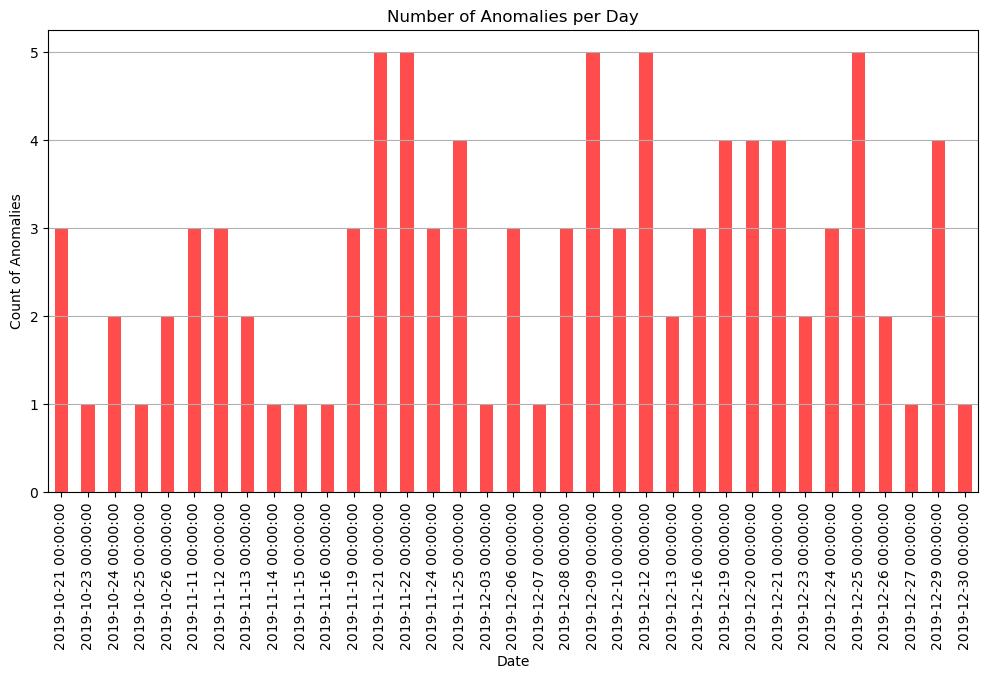

In [12]:
# --- Required Parameters and Indices ---
SEQUENCE_LENGTH = 24
# The number of test sequences (length of y_test)
test_size = len(y_test)
# The starting index of the test set within the total sequences array (X_multi)
train_val_end_index = len(X_multi) - test_size

# --- 1. Extract Anomaly Indices from the Test Set (y_pred) ---
# Finds the indices within the y_pred array where an anomaly (1) was predicted.
anomaly_sequence_indices_in_test = np.where(y_pred == 1)[0]

# --- 2. Calculate Absolute Anomaly Indices in the Original DataFrame (df) ---

# We need to map the relative index 'i' in the test set to the absolute row index in the original 'df'.
# The formula is: (Start of Test Sequences in X) + (Relative Index in Test) + (Sequence length adjustment)
# The sequence end time is taken as the anomaly time:
anomaly_indices_full = [
    train_val_end_index + i + SEQUENCE_LENGTH - 1
    for i in anomaly_sequence_indices_in_test
]

# --- 3. Verify the Calculated Indices ---
# Check the first and last mapped anomaly dates to ensure the mapping is correct
if anomaly_indices_full:
    first_anomaly_date = df.index[anomaly_indices_full[0]]
    last_anomaly_date = df.index[anomaly_indices_full[-1]]
    print(f" Anomalies mapped between dates: {first_anomaly_date} and {last_anomaly_date}.")
else:
    print("No anomalies detected in the test set.")


# --- 4. Count Anomalies by Date ---

# Use the calculated indices to slice the original DataFrame, get the datetime index,
# normalize it (to get just the date/start of the day), count the occurrences, and sort by date.
anomaly_day_counts = df.iloc[anomaly_indices_full].index.normalize().value_counts().sort_index()

print("\nAnomaly counts per day (Test Set):")
print(anomaly_day_counts)



plt.figure(figsize=(12,6))
anomaly_day_counts.plot(kind='bar', color='red', alpha=0.7)
plt.title("Number of Anomalies per Day")
plt.xlabel("Date")
plt.ylabel("Count of Anomalies")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.show()
